# DTSC 2302 Final Project Technical Report

## Predicting Student Academic Performance Using Lifestyle and Study Habits

**Haoran Chen, Ian Basora, Zen Sadler**  
DTSC 2302  
Spring 2026

This notebook combines the preprocessing notebook and the modeling notebook into one complete technical report. It follows the same central story as the public portfolio post: student habit data can help identify academic risk, but the results must be interpreted carefully because student success is shaped by personal habits, prior academic history, and outside responsibilities.

## 1. Project Purpose

The goal of this project is to test whether survey based student information can predict whether a student passes or fails. The project is socially relevant because schools often want to identify academic risk early enough to offer useful support. The technical purpose is to document the full data science workflow, including dataset review, preprocessing, modeling, evaluation, interpretation, limitations, and ethical concerns.

This report stays connected to the public portfolio post by answering the same three research questions: whether habits predict pass or fail, whether income or part time work appears as a disadvantage, and whether prior academic scores outweigh lifestyle variables.

## 2. Dataset Source and Research Context

The dataset is the Student Performance Metrics Dataset by Hasan, Hasan, and Manzoor. It was published on Mendeley Data in 2024 and contains survey responses from 493 undergraduate students at Universiti Malaya. It was a useful dataset for this project because it required real preprocessing decisions before any model could be built.

The variables cover academic background, lifestyle patterns, and demographics. The academic variables include HSC, SSC, last semester performance, and overall CGPA. The lifestyle variables include preparation time, gaming time, attendance, part time job status, extracurricular participation, English proficiency, and computer proficiency. The background variables include department, gender, family income, hometown, and semester.

The main modeling task is binary classification. Overall CGPA is converted into a pass or fail label using 2.5 as the cutoff. This matches the public portfolio post and creates the same class balance discussed there: 429 passing students and 64 failing students.

## 3. Analysis Plan

The analysis moves through the full data science pipeline in a clear order. First, the raw dataset is loaded and checked for size, variable types, and missing values. Next, the target variable is created from CGPA. After that, exploratory charts are used to understand the class balance, CGPA distribution, lifestyle patterns, and numeric correlations.

The modeling phase compares three models: Logistic Regression, Random Forest, and XGBoost. Logistic Regression is used as the baseline because it is simple and easy to explain. Random Forest is included because it improves stability by combining many tree learners and provides feature importance values. XGBoost is a more advanced gradient boosting model, and it is useful because it builds a sequence of boosted learners that correct earlier errors.

The evaluation focuses on the fail group. Accuracy is reported, but it is not treated as the main measure because 87 percent of students passed. A model could look accurate by predicting almost every student as passing. For this reason, fail precision, fail recall, fail F1, and missed fails are more meaningful for the goal of early intervention.

## 4. Import Libraries

This cell imports the libraries used throughout the notebook. Pandas and NumPy handle the data. Matplotlib creates the charts. Scikit learn provides preprocessing, splitting, the baseline model, the Random Forest model, cross validation, and evaluation metrics. XGBoost provides the advanced boosting model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
PASS_THRESHOLD = 2.5

print('Libraries loaded successfully')


Libraries loaded successfully


## 5. Load the Raw Dataset

The code below checks common file locations so the notebook can run in either Google Colab or a local Jupyter environment. The expected file name is ResearchInformation3.csv. Loading the raw file in this combined report keeps the work reproducible and avoids depending on the previous notebooks.

In [2]:
possible_paths = [
    Path('/content/drive/MyDrive/ResearchInformation3.csv'),
    Path('ResearchInformation3.csv'),
    Path('/mnt/data/ResearchInformation3.csv')
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError('Place ResearchInformation3.csv in the notebook folder or in Google Drive')

df_raw = pd.read_csv(data_path)
df = df_raw.copy()

print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
df.head()


Rows: 493
Columns: 16


,Department,Gender,HSC,SSC,Income,Hometown,Computer,Preparation,Gaming,Attendance,Job,English,Extra,Semester,Last,Overall
0,Business Administration,Male,4.17,4.84,"Low (Below 15,000)",Village,3,More than 3 Hours,0-1 Hour,80%-100%,No,3,Yes,6th,3.220,3.350
1,Business Administration,Female,4.92,5.00,"Upper middle (30,000-50,000)",City,3,0-1 Hour,0-1 Hour,80%-100%,No,3,Yes,7th,3.467,3.467
2,Business Administration,Male,5.00,4.83,"Lower middle (15,000-30,000)",Village,3,0-1 Hour,More than 3 Hours,80%-100%,No,4,Yes,3rd,4.000,3.720
3,Business Administration,Male,4.00,4.50,"High (Above 50,000)",City,5,More than 3 Hours,More than 3 Hours,80%-100%,No,5,Yes,4th,3.800,3.750
4,Business Administration,Female,2.19,3.17,"Lower middle (15,000-30,000)",Village,3,0-1 Hour,2-3 Hours,80%-100%,No,3,Yes,4th,3.940,3.940


## 6. Initial Dataset Review

This section checks whether the imported dataset matches the expected structure. The row count confirms the number of students. The column review confirms that the dataset includes both numeric and categorical variables. This matters because the preprocessing steps depend on the column type.

The summary statistics are also important for checking that the analysis is using the right variables. HSC, SSC, computer proficiency, English proficiency, last semester performance, and overall CGPA are numeric. Department, gender, income, hometown, preparation time, gaming time, attendance category, job status, extracurricular activity, and semester are categorical.

In [3]:
print('Dataset shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nNumeric summary:')
df.describe()


Dataset shape: (493, 16)

Column names:
['Department', 'Gender', 'HSC', 'SSC', 'Income', 'Hometown', 'Computer', 'Preparation', 'Gaming', 'Attendance', 'Job', 'English', 'Extra', 'Semester', 'Last', 'Overall']

Data types:
Department      object
Gender          object
HSC            float64
SSC            float64
Income          object
Hometown        object
Computer         int64
Preparation     object
Gaming          object
Attendance      object
Job             object
English          int64
Extra           object
Semester        object
Last           float64
Overall        float64
dtype: object

Numeric summary:


,HSC,SSC,Computer,English,Last,Overall
count,493.000000,493.000000,493.000000,493.000000,493.000000,493.000000
mean,4.156775,4.767647,3.338742,3.569980,3.163888,3.188383
std,0.546504,0.349538,1.252988,0.870515,0.641475,0.591801
min,2.170000,3.000000,1.000000,1.000000,1.000000,1.000000
25%,3.830000,4.680000,3.000000,3.000000,2.810000,2.880000
50%,4.170000,4.940000,3.000000,4.000000,3.250000,3.270000
75%,4.500000,5.000000,4.000000,4.000000,3.670000,3.680000
max,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000


## 7. Missing Values and Cleaning Assumptions

The uploaded preprocessing notebook already showed that the dataset had no missing values. The cleaning code is still included because it makes the workflow safe to rerun. If a numeric value is missing, the median is used because it is less affected by extreme values than the mean. If a categorical value is missing, the mode is used because it keeps the most common response in that category.

This is a conservative cleaning choice. It avoids deleting student records, which is useful because the fail group is already small.

In [4]:
missing_before = df.isnull().sum()
print('Missing values before cleaning:')
print(missing_before)

for column in df.select_dtypes(include=[np.number]).columns:
    df[column] = df[column].fillna(df[column].median())

for column in df.select_dtypes(include='object').columns:
    df[column] = df[column].fillna(df[column].mode()[0])

missing_after = df.isnull().sum()
print('\nMissing values after cleaning:')
print(missing_after)


Missing values before cleaning:
Department     0
Gender         0
HSC            0
SSC            0
Income         0
Hometown       0
Computer       0
Preparation    0
Gaming         0
Attendance     0
Job            0
English        0
Extra          0
Semester       0
Last           0
Overall        0
dtype: int64

Missing values after cleaning:
Department     0
Gender         0
HSC            0
SSC            0
Income         0
Hometown       0
Computer       0
Preparation    0
Gaming         0
Attendance     0
Job            0
English        0
Extra          0
Semester       0
Last           0
Overall        0
dtype: int64


## 8. Target Variable

Overall CGPA is the original outcome variable. To answer the project question, it is converted into pass_fail. A value of 1 means the student passed with an Overall CGPA of at least 2.5. A value of 0 means the student fell below that cutoff.

The cutoff creates a class imbalance. There are many more passing students than failing students. This directly affects the evaluation plan because accuracy alone could make a weak model look strong.

In [5]:
df['pass_fail'] = (df['Overall'] >= PASS_THRESHOLD).astype(int)

class_counts = df['pass_fail'].value_counts().sort_index()
fail_count = int(class_counts.loc[0])
pass_count = int(class_counts.loc[1])
pass_rate = pass_count / len(df)

print(f'Fail count: {fail_count}')
print(f'Pass count: {pass_count}')
print(f'Pass rate: {pass_rate:.1%}')


Fail count: 64
Pass count: 429
Pass rate: 87.0%


## 9. Class Balance Visualization

This chart shows why the fail group needs special attention. The pass group is much larger than the fail group. In a student support setting, the main risk is not only making wrong predictions. The more serious risk is missing students who may need help.

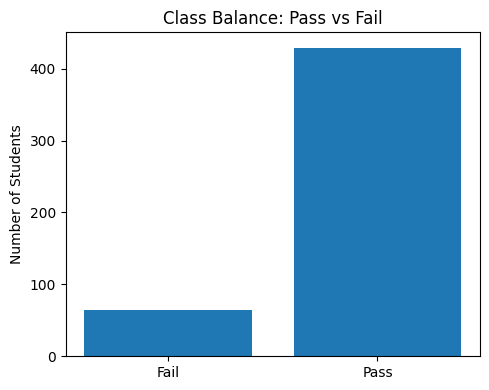

In [6]:
counts = df['pass_fail'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Fail', 'Pass'], counts.values)
ax.set_title('Class Balance: Pass vs Fail')
ax.set_ylabel('Number of Students')
plt.tight_layout()
plt.show()


## 10. CGPA Distribution

The histogram shows how student CGPA values are distributed around the 2.5 cutoff. Most students are above the cutoff, which explains the imbalance. The students just below 2.5 are especially important because they may be close enough to benefit from early advising, tutoring, or attendance support.

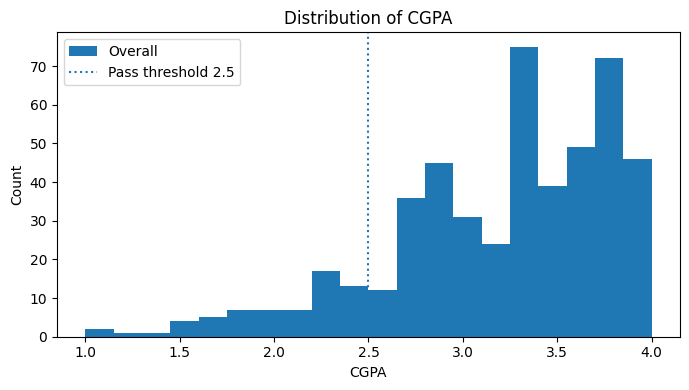

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
df['Overall'].plot(kind='hist', bins=20, ax=ax)
ax.axvline(PASS_THRESHOLD, linestyle='dotted', label=f'Pass threshold {PASS_THRESHOLD}')
ax.set_title('Distribution of CGPA')
ax.set_xlabel('CGPA')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


## 11. Lifestyle Patterns by Outcome

This section examines the lifestyle variables most connected to the portfolio post: preparation time, gaming time, and attendance. The purpose is not to prove causation. The purpose is to see whether the patterns are strong enough to justify using these variables in the modeling stage.

The chart supports the public story. Students with stronger attendance and preparation patterns generally show better outcomes. Students with very high gaming time and very low attendance show a larger share of fail outcomes.

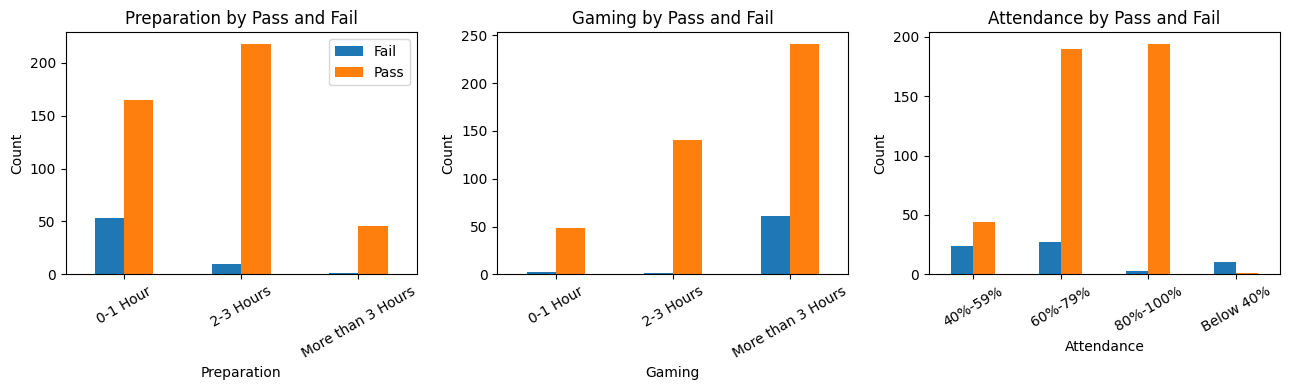

In [8]:
key_features = ['Preparation', 'Gaming', 'Attendance']
key_features = [feature for feature in key_features if feature in df.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(13, 4))
for index, feature in enumerate(key_features):
    grouped = df.groupby([feature, 'pass_fail']).size().unstack(fill_value=0)
    grouped.plot(kind='bar', ax=axes[index], legend=(index == 0))
    axes[index].set_title(f'{feature} by Pass and Fail')
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel('Count')
    axes[index].tick_params(axis='x', rotation=30)
    if index == 0:
        axes[index].legend(['Fail', 'Pass'])
plt.tight_layout()
plt.show()


## 12. Numeric Correlation Review

The heatmap checks the relationship between numeric variables. Last semester performance has the strongest relationship with the pass_fail target. That result is expected because recent academic performance usually carries forward into current academic performance.

The important interpretation is that prior performance matters, but it does not fully replace lifestyle variables. The portfolio post makes the same point: habits and attendance still carry useful information, especially when the goal is student support rather than ranking students.

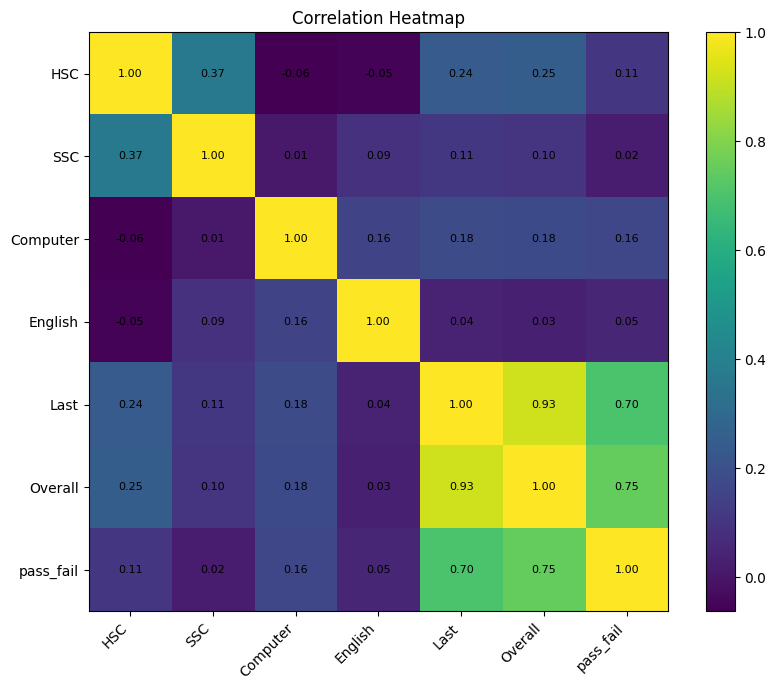

In [9]:
numeric_data = df.select_dtypes(include=[np.number])
corr = numeric_data.corr()

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr)
ax.set_title('Correlation Heatmap')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for row in range(len(corr.columns)):
    for col in range(len(corr.columns)):
        ax.text(col, row, f'{corr.iloc[row, col]:.2f}', ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 13. Feature Preparation

The outcome variable Overall is removed before modeling because it was used to create pass_fail. Keeping Overall in the feature set would leak the answer into the model and make the results invalid.

Categorical variables are converted into numeric indicator columns with one hot encoding. Drop first is used to reduce repeated information among categories. Standard scaling is applied after encoding so numeric variables are placed on comparable scales. This helps Logistic Regression in particular, while keeping all three models in the same prepared feature space.

In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

model_data = df.drop(columns=['Overall'])
encoded = pd.get_dummies(
    model_data,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

feature_cols = [column for column in encoded.columns if column != 'pass_fail']
scaled = encoded.copy()
scaler = StandardScaler()
scaled[feature_cols] = scaler.fit_transform(encoded[feature_cols])

print(f'Rows after encoding: {scaled.shape[0]}')
print(f'Columns after encoding: {scaled.shape[1]}')
print(f'Features used for modeling: {len(feature_cols)}')


Rows after encoding: 493
Columns after encoding: 45
Features used for modeling: 44


## 14. Train and Test Split

The data is split into training and testing sets using an 80 percent training set and a 20 percent test set. Stratification is used so the pass and fail proportions stay similar in both sets. This is important because the fail group is small, and a random split without stratification could create an uneven test set.

A fixed random state is used so the results can be reproduced.

In [11]:
X = scaled.drop(columns=['pass_fail'])
y = scaled['pass_fail']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')
print(f'Feature count: {X_train.shape[1]}')
print('\nTraining class counts:')
print(y_train.value_counts().sort_index())
print('\nTest class counts:')
print(y_test.value_counts().sort_index())


Training samples: 394
Test samples: 99
Feature count: 44

Training class counts:
pass_fail
0     51
1    343
Name: count, dtype: int64

Test class counts:
pass_fail
0    13
1    86
Name: count, dtype: int64


## 15. Evaluation Functions

The evaluation function reports accuracy, fail precision, fail recall, fail F1, and missed fails. The fail group is treated as the priority class because the purpose of the project is to identify academic risk. Missed fails are especially important because they represent students who failed but were predicted as passing.

The cross validation scorer also uses fail F1. This keeps the evaluation aligned with the project question rather than defaulting to the pass group.

In [12]:
def evaluate_model(model_name, actual, predicted):
    cm = confusion_matrix(actual, predicted, labels=[0, 1])
    result = {
        'Model': model_name,
        'Accuracy': accuracy_score(actual, predicted),
        'Fail Precision': precision_score(actual, predicted, pos_label=0, zero_division=0),
        'Fail Recall': recall_score(actual, predicted, pos_label=0, zero_division=0),
        'Fail F1': f1_score(actual, predicted, pos_label=0, zero_division=0),
        'Missed Fails': int(cm[0, 1])
    }
    return result, cm

fail_f1_scorer = make_scorer(f1_score, pos_label=0, zero_division=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Evaluation functions ready')


Evaluation functions ready


## 16. Model One: Logistic Regression

Logistic Regression is the baseline model. It learns a weighted relationship between each feature and the probability of passing. It is useful because the results are easy to compare against more complex models.

Class weight balanced is used because the fail group is much smaller than the pass group. This prevents the model from treating the majority pass group as the only important outcome.

In [13]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_result, lr_cm = evaluate_model('Logistic Regression', y_test, lr_pred)
lr_cv = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring=fail_f1_scorer)
lr_result['CV Fail F1 Mean'] = lr_cv.mean()
lr_result['CV Fail F1 Std'] = lr_cv.std()

print('Model: Logistic Regression')
print(f"Accuracy: {lr_result['Accuracy']:.4f}")
print(f"Fail Precision: {lr_result['Fail Precision']:.4f}")
print(f"Fail Recall: {lr_result['Fail Recall']:.4f}")
print(f"Fail F1: {lr_result['Fail F1']:.4f}")
print(f"Missed Fails: {lr_result['Missed Fails']}")

Model: Logistic Regression
Accuracy: 0.9596
Fail Precision: 0.9091
Fail Recall: 0.7692
Fail F1: 0.8333
Missed Fails: 3


The next cell visualizes the Logistic Regression confusion matrix. The top row represents students who actually failed. The value in the top right cell is the most important error because it shows failing students predicted as passing.

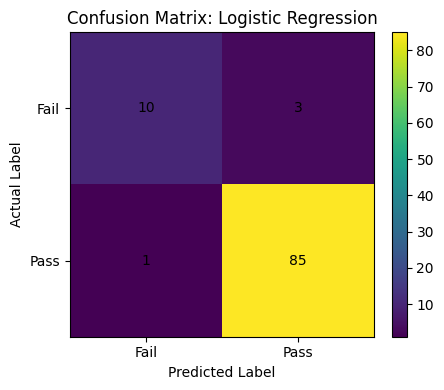

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(lr_cm)
ax.set_title('Confusion Matrix: Logistic Regression')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Fail', 'Pass'])
ax.set_yticklabels(['Fail', 'Pass'])
for row in range(2):
    for col in range(2):
        ax.text(col, row, str(lr_cm[row, col]), ha='center', va='center')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 17. Model Two: Random Forest

Random Forest trains many tree learners and combines their predictions. This usually gives better stability than a single learner because each learner sees a different sample of the data and a different subset of features.

This model is important for interpretation because it provides feature importance scores. Those scores help explain which variables the model used most often when predicting pass or fail.

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_result, rf_cm = evaluate_model('Random Forest', y_test, rf_pred)
rf_cv = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring=fail_f1_scorer)
rf_result['CV Fail F1 Mean'] = rf_cv.mean()
rf_result['CV Fail F1 Std'] = rf_cv.std()

print('Model: Random Forest')
print(f"Accuracy: {rf_result['Accuracy']:.4f}")
print(f"Fail Precision: {rf_result['Fail Precision']:.4f}")
print(f"Fail Recall: {rf_result['Fail Recall']:.4f}")
print(f"Fail F1: {rf_result['Fail F1']:.4f}")
print(f"Missed Fails: {rf_result['Missed Fails']}")

Model: Random Forest
Accuracy: 0.9798
Fail Precision: 1.0000
Fail Recall: 0.8462
Fail F1: 0.9167
Missed Fails: 2


The next cell visualizes the Random Forest confusion matrix. This model is important because the public portfolio post uses Random Forest as the main interpretable model. The matrix shows how many fail and pass cases were handled correctly on the test set.

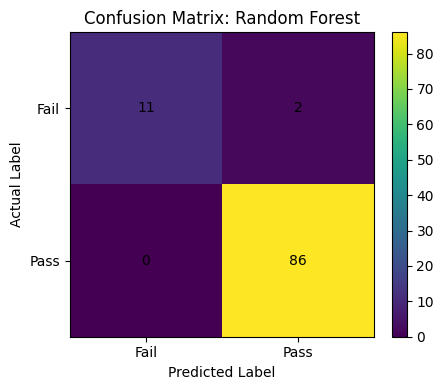

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(rf_cm)
ax.set_title('Confusion Matrix: Random Forest')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Fail', 'Pass'])
ax.set_yticklabels(['Fail', 'Pass'])
for row in range(2):
    for col in range(2):
        ax.text(col, row, str(rf_cm[row, col]), ha='center', va='center')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 18. Model Three: XGBoost

XGBoost is a gradient boosting model, which means it builds trees in sequence. Each new tree tries to correct errors left by the earlier trees.

This model is useful for this project because student performance patterns may not be linear. For example, attendance and preparation may matter differently depending on prior grades or other background factors. The labels use pass as 1 and fail as 0, so the scale value reduces the influence of the larger pass class and gives the fail cases more relative importance.

In [17]:
failing_students = int((y_train == 0).sum())
passing_students = int((y_train == 1).sum())
scale_for_pass_class = failing_students / passing_students

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_for_pass_class,
    eval_metric='logloss',
    random_state=RANDOM_STATE
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_result, xgb_cm = evaluate_model('XGBoost', y_test, xgb_pred)
xgb_cv = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring=fail_f1_scorer)
xgb_result['CV Fail F1 Mean'] = xgb_cv.mean()
xgb_result['CV Fail F1 Std'] = xgb_cv.std()

print('Model: XGBoost')
print(f"Accuracy: {xgb_result['Accuracy']:.4f}")
print(f"Fail Precision: {xgb_result['Fail Precision']:.4f}")
print(f"Fail Recall: {xgb_result['Fail Recall']:.4f}")
print(f"Fail F1: {xgb_result['Fail F1']:.4f}")
print(f"Missed Fails: {xgb_result['Missed Fails']}")

Model: XGBoost
Accuracy: 0.9798
Fail Precision: 0.8667
Fail Recall: 1.0000
Fail F1: 0.9286
Missed Fails: 0


The next cell visualizes the XGBoost confusion matrix. This is used to compare the boosted model against the simpler models and to check whether it missed students in the fail group.

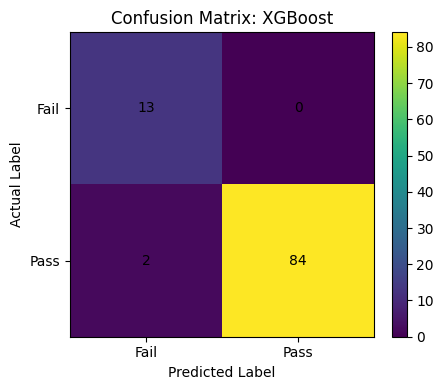

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(xgb_cm)
ax.set_title('Confusion Matrix: XGBoost')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Fail', 'Pass'])
ax.set_yticklabels(['Fail', 'Pass'])
for row in range(2):
    for col in range(2):
        ax.text(col, row, str(xgb_cm[row, col]), ha='center', va='center')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 19. Model Comparison and Interpretation

The models are compared using the same train and test split. Logistic Regression provides the baseline. Random Forest provides the strongest interpretable ensemble model. XGBoost provides a more flexible boosted tree approach.

The strongest model depends on the goal. Random Forest produced the strongest overall fail F1 in the saved results, while XGBoost found every failing student in the test set. For an early warning system, missing fewer failing students may be worth a few extra false alarms, as long as the response is supportive rather than punitive.

In [19]:
all_results = pd.DataFrame([lr_result, rf_result, xgb_result])
number_cols = ['Accuracy', 'Fail Precision', 'Fail Recall', 'Fail F1', 'CV Fail F1 Mean', 'CV Fail F1 Std']
all_results[number_cols] = all_results[number_cols].round(4)
all_results.sort_values(by='Fail F1', ascending=False)


,Model,Accuracy,Fail Precision,Fail Recall,Fail F1,Missed Fails,CV Fail F1 Mean,CV Fail F1 Std
2,XGBoost,0.9798,0.8667,1.0000,0.9286,0,0.8514,0.0588
1,Random Forest,0.9798,1.0000,0.8462,0.9167,2,0.8377,0.0794
0,Logistic Regression,0.9596,0.9091,0.7692,0.8333,3,0.8006,0.0807


The next cell creates a recall comparison chart. It focuses on how many failing students each model found, which fits the early support purpose of the project better than accuracy alone.

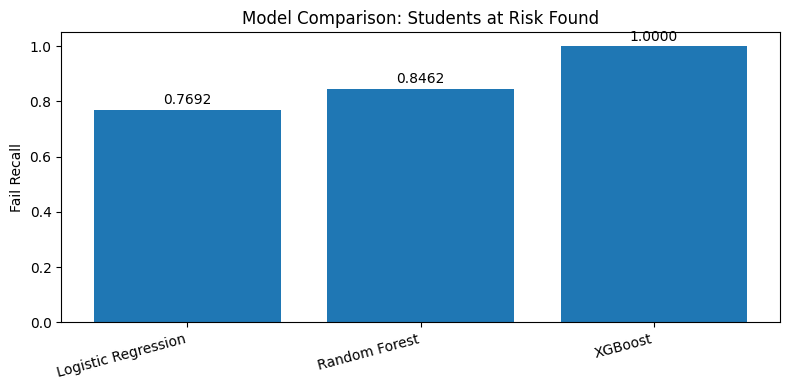

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(all_results['Model'], all_results['Fail Recall'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Fail Recall')
ax.set_title('Model Comparison: Students at Risk Found')
for index, value in enumerate(all_results['Fail Recall']):
    ax.text(index, value + 0.02, f'{value:.4f}', ha='center')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


## 20. Feature Importance

Feature importance helps explain what the ensemble models relied on. In the Random Forest output, last semester performance was the strongest predictor. That result makes sense because recent grades are closely connected to current CGPA.

The more important interpretation is that behavioral variables still appear in the model. Attendance, preparation, and gaming patterns add information beyond prior scores. That is the link back to the portfolio post: student habits do not tell the whole story, but they provide signals that may help advisors notice risk earlier.

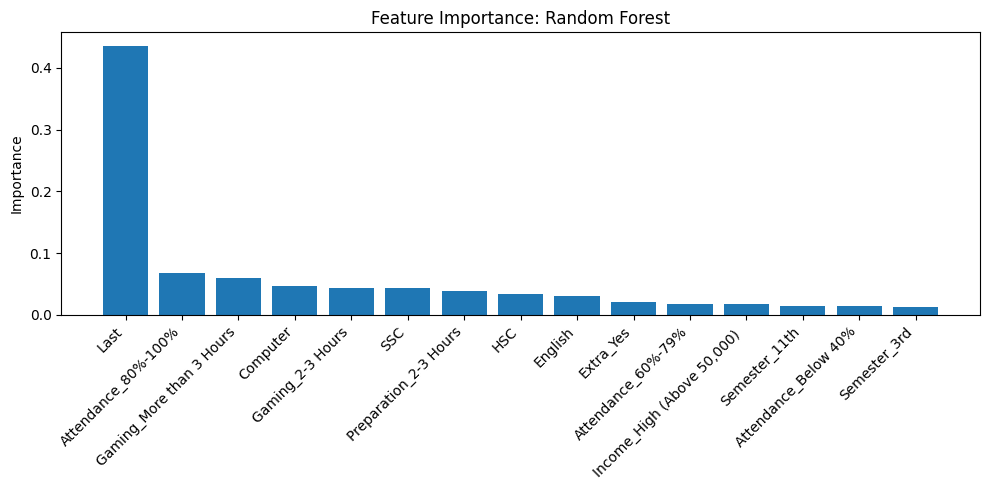

,0
Last,0.435944
Attendance_80%-100%,0.067263
Gaming_More than 3 Hours,0.059369
Computer,0.047706
Gaming_2-3 Hours,0.044402
SSC,0.043311
Preparation_2-3 Hours,0.038165
HSC,0.034220
English,0.030271
Extra_Yes,0.020670


In [21]:
def plot_feature_importance(model, model_name, top_n=15):
    importance = pd.Series(model.feature_importances_, index=X_train.columns)
    top = importance.sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(range(len(top)), top.values)
    ax.set_xticks(range(len(top)))
    ax.set_xticklabels(top.index, rotation=45, ha='right')
    ax.set_title(f'Feature Importance: {model_name}')
    ax.set_ylabel('Importance')
    plt.tight_layout()
    plt.show()

    return top

rf_top_features = plot_feature_importance(rf_model, 'Random Forest')
rf_top_features


The next cell repeats the same feature importance process for XGBoost. Comparing Random Forest and XGBoost helps show whether the stronger models relied on similar predictors.

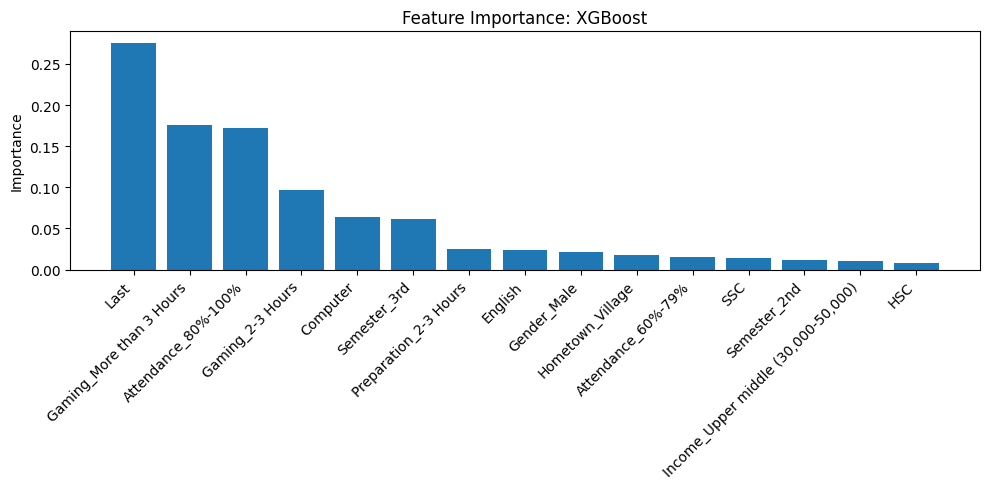

,0
Last,0.275861
Gaming_More than 3 Hours,0.176319
Attendance_80%-100%,0.171578
Gaming_2-3 Hours,0.097084
Computer,0.064534
Semester_3rd,0.061837
Preparation_2-3 Hours,0.025251
English,0.023708
Gender_Male,0.021285
Hometown_Village,0.017919


In [22]:
xgb_top_features = plot_feature_importance(xgb_model, 'XGBoost')
xgb_top_features


## 21. Feature Group Experiment

The portfolio post asks whether prior academic scores outweigh lifestyle factors. To test that question more directly, this section separates the features into two groups.

The first group uses all available features after removing the target. The second group keeps lifestyle and support related variables such as preparation, gaming, attendance, job status, extracurricular activity, income, computer proficiency, and English proficiency. The purpose is to see whether lifestyle features still carry predictive value without relying as heavily on prior academic performance.

This experiment is useful because a model dominated by last semester performance may mostly identify students who were already struggling. Lifestyle features are more actionable because schools can respond with tutoring, advising, attendance support, or workload conversations.

In [23]:
lifestyle_keywords = [
    'Preparation',
    'Gaming',
    'Attendance',
    'Job',
    'Extra',
    'Income',
    'Computer',
    'English'
]

lifestyle_cols = [
    column for column in X.columns
    if any(keyword in column for keyword in lifestyle_keywords)
]

X_life = X[lifestyle_cols]
X_life_train, X_life_test, y_life_train, y_life_test = train_test_split(
    X_life,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

life_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

life_model.fit(X_life_train, y_life_train)
life_pred = life_model.predict(X_life_test)
life_result, life_cm = evaluate_model('Lifestyle Features Only', y_life_test, life_pred)

comparison_focus = pd.DataFrame([rf_result, life_result])
comparison_focus[['Accuracy', 'Fail Precision', 'Fail Recall', 'Fail F1']] = comparison_focus[
    ['Accuracy', 'Fail Precision', 'Fail Recall', 'Fail F1']
].round(4)
comparison_focus


,Model,Accuracy,Fail Precision,Fail Recall,Fail F1,Missed Fails,CV Fail F1 Mean,CV Fail F1 Std
0,Random Forest,0.9798,1.0000,0.8462,0.9167,2,0.837744,0.079439
1,Lifestyle Features Only,0.8990,0.7143,0.3846,0.5000,8,NaN,NaN


## 22. Answers to the Research Questions

**Research Question 1: Can habits predict pass or fail?**  
Yes. Attendance, preparation time, and gaming time showed visible differences between passing and failing students. The models also used these variables when predicting outcomes. This does not prove that a habit directly causes a grade, but it shows that the habits are useful signals within this dataset.

**Research Question 2: Does income or part time work appear as a disadvantage?**  
Partially. Income and job status are present in the feature set, but they are not the strongest direct predictors. The stronger finding is that the most actionable risk signals, especially attendance and preparation time, may be affected by work schedules and family resources. This means income should be interpreted as context, not as a label about student ability.

**Research Question 3: Do prior scores outweigh lifestyle factors?**  
Prior academic performance matters, especially last semester GPA. However, lifestyle factors still add information. This is important because last semester GPA mostly tells the school who has already struggled. Attendance and preparation signals may help identify support needs earlier.

## 23. Limitations, Assumptions, and Ethics

The dataset represents 493 students at one university in Malaysia. The findings should not be generalized to other colleges without testing the model on local data. Different schools may have different grading systems, attendance policies, work expectations, and student support systems.

The data is also a single snapshot. It does not show how a student changes over time. A student with a sudden drop in attendance after a personal problem looks the same as a student with consistently low attendance. A stronger future project would use weekly or monthly data so the model could detect changes earlier.

The pass fail target also loses information. A student with a 2.49 CGPA and a student with a 1.00 CGPA are both labeled as failing, even though their support needs may be very different. A regression model predicting CGPA or a risk level model with several categories could give a more careful result.

The model shows correlation, not causation. It can show that attendance is connected to passing, but it cannot prove that attendance alone caused the outcome. Motivation, health, family obligations, course difficulty, transportation, and access to support could all influence both attendance and GPA.


## 24. Ethical Risks and Responsible Use

This project has a clear social purpose because it asks whether student lifestyle and academic background data can help identify students who may need support. That purpose is useful, but it also creates risk. The main ethical concern is that a model built for support could be used as a label. If an advisor, instructor, or school office treated the prediction as proof that a student was going to fail, the student could be judged before anyone understood the situation behind the data.

One harmful outcome would be stigma. A student flagged as at risk might feel watched, embarrassed, or treated as less capable. This is especially serious when the model uses information such as attendance, income, job status, and prior grades. Low attendance might come from work, illness, transportation problems, caregiving, or financial pressure. A model cannot tell the difference between a student who is disengaged and a student who is carrying responsibilities outside school.

Another risk is proxy bias. Family income, hometown, part time work, and attendance can reflect structural disadvantage. If those variables help predict failure, the model may be learning patterns of inequality rather than patterns of ability. A lower income student may have fewer study hours because of work or commute demands, not because of lower motivation. Using that prediction carelessly could reinforce the same barriers the school should be trying to reduce.

False predictions also matter. A false positive could label a student as needing academic intervention when the student is actually doing fine. That could create stress or unnecessary pressure. A false negative could miss a student who truly needs help. For this project, missing a struggling student is the more serious technical concern, which is why fail recall and fail F1 were emphasized instead of accuracy alone.

The responsible response is to treat the model as a conversation starter, not a decision maker. A prediction should lead to supportive outreach, tutoring options, advising, attendance support, financial resources, or a check in from someone who can understand context. It should not be used to punish students, remove opportunities, lower expectations, or make assumptions about effort.

A responsible version of this project would include human review before any action is taken. It would also require privacy protection, clear explanation of why a student was flagged, and fairness checks across income level, gender, department, job status, and other groups. Income should be used carefully as a fairness evaluation variable, not as a direct judgment of student ability. The ethical value of the project depends on what happens after the prediction. Used carefully, the model could help students receive support earlier. Used carelessly, it could turn personal hardship into a data label.


## 25. Reproducibility and Code Quality

The workflow is organized so another person can follow the project from raw data to final model interpretation. The notebook uses one random state, a stratified train and test split, consistent metrics, clear feature preparation, and separate model sections.

The code also saves the main outputs so the poster, portfolio post, and technical report can use the same results. This keeps the group deliverables consistent instead of creating separate numbers in different files.

In [24]:
all_results.to_csv('model_results.csv', index=False)
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print('Saved model_results.csv')
print('Saved X_train.csv and X_test.csv')
print('Saved y_train.csv and y_test.csv')


Saved model_results.csv
Saved X_train.csv and X_test.csv
Saved y_train.csv and y_test.csv


## 26. References and AI Transparency

Hasan, T., Hasan, M., and Manzoor, T. 2024. Student Performance Metrics Dataset. Mendeley Data, Version 1. DOI: 10.17632/5b82ytz489.1

Kuh, G. D., Kinzie, J. A., Buckley, J. A., Bridges, B. K., and Hayek, J. C. 2006. What Matters to Student Success: A Review of the Literature. National Postsecondary Education Cooperative.

Tinto, V. 1987. Leaving College: Rethinking the Causes and Cures of Student Attrition. University of Chicago Press.

Libraries used in the workflow include pandas, NumPy, Matplotlib, scikit learn, and XGBoost.

AI transparency: Claude was used earlier in the project for code debugging and structural guidance during preprocessing and portfolio organization. The research question, dataset selection, modeling choices, interpretation, and final conclusions reflect the project team decisions.